In [ ]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#load the dataset
ds=pd.read_csv('/content/advertising.csv')
print('DataSet loaded successfully');

DataSet loaded successfully


In [ ]:
ds.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
ds.shape

(200, 4)

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
ds.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
#detecting missing values
ds.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
ds.drop('Radio',axis=1,inplace=True)
ds.drop('Newspaper',axis=1,inplace=True)

In [ ]:
#converts Sales to the nearest lower integer by removing decimal values
ds['Sales']=ds['Sales'].apply(np.floor)
ds

,TV,Sales
0,230.1,22.0
1,44.5,10.0
2,17.2,12.0
3,151.5,16.0
4,180.8,17.0
...,...,...
195,38.2,7.0
196,94.2,14.0
197,177.0,14.0
198,283.6,25.0


In [ ]:
#independent variable select all rows,all columns except last column
x=ds.iloc[:,:-1]
x

,TV
0,230.1
1,44.5
2,17.2
3,151.5
4,180.8
...,...
195,38.2
196,94.2
197,177.0
198,283.6


In [ ]:
#dependent
y=ds.iloc[:,-1]
y

,Sales
0,22.0
1,10.0
2,12.0
3,16.0
4,17.0
...,...
195,7.0
196,14.0
197,14.0
198,25.0


In [ ]:
#split the data into training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#create the model
model=LinearRegression()
print("Model created Successfully")

Model created Successfully


In [ ]:
#train the model
model.fit(x_train,y_train)
print("Model is Trained")

Model is Trained


In [ ]:
#Generate predictions for training and testing datasets using the trained model
y_train_pred=model.predict(x_train)
y_test_pred=model.predict(x_test)
print("Predictions generated for both training and testing")

Predictions generated for both training and testing


In [ ]:
# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
print("Model Evaluation Metrics")
print("Mean Absolute Error(MAE):",mean_squared_error(y_train,y_train_pred))
print("Mean Squared Error(MSE):",mean_squared_error(y_train,y_train_pred))
print("Root Mean Squared Error(RMSE):",np.sqrt(mean_squared_error(y_train,y_train_pred)))
print("R2 Score:",r2_score(y_train,y_train_pred))

Model Evaluation Metrics
Mean Absolute Error(MAE): 5.12192253544143
Mean Squared Error(MSE): 5.12192253544143
Root Mean Squared Error(RMSE): 2.263166484251972
R2 Score: 0.809891829995548


In [ ]:
#slope
model.coef_

array([0.05550749])

In [ ]:
#intercept
model.intercept_

np.float64(6.554051120262805)

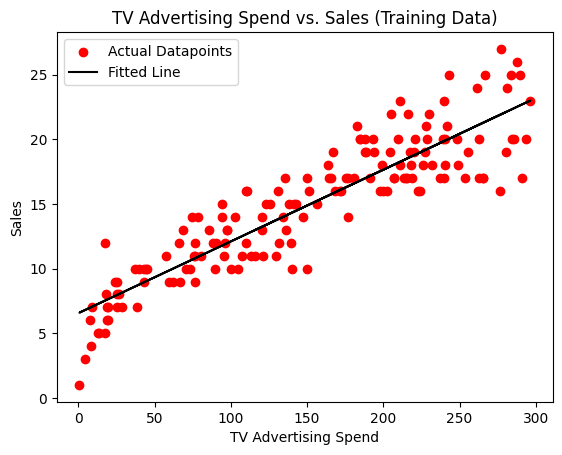

In [ ]:
#plot actual training datapoints and fitted linear regression line for visualization
plt.scatter(x_train['TV'],y_train,color='red',label='Actual Datapoints')
plt.plot(x_train['TV'],y_train_pred,color='black',label='Fitted Line')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.title('TV Advertising Spend vs. Sales (Training Data)')
plt.legend()
plt.show()